

Data Wrangling (Data Cleaning & Preprocessing)

During the data wrangling stage, the Airbnb dataset was carefully cleaned and transformed to ensure accuracy and consistency. The following steps were performed:



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
#read the Airbnb data
df =pd.read_csv('/content/1730285881-Airbnb_Open_Data.csv',low_memory=False)

In [4]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,8.001449e+10,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,19-10-2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,5.233517e+10,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,21-05-2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,7.882924e+10,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,8.509833e+10,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,05-07-2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,9.203760e+10,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,19-11-2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10562 entries, 0 to 10561
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              10562 non-null  int64  
 1   NAME                            10498 non-null  object 
 2   host id                         10562 non-null  int64  
 3   host_identity_verified          10467 non-null  object 
 4   host name                       10534 non-null  object 
 5   neighbourhood group             10535 non-null  object 
 6   neighbourhood                   10546 non-null  object 
 7   lat                             10554 non-null  float64
 8   long                            10554 non-null  float64
 9   country                         10512 non-null  object 
 10  country code                    10483 non-null  object 
 11  instant_bookable                10483 non-null  object 
 12  cancellation_policy             

In [ ]:
df.duplicated().value_counts()


,count
False,10562


In [ ]:
#neighbourhood group was brookln instead of 'Brooklyn'
df[df['neighbourhood group'] == 'brookln']

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
13,1008516,"Lovely Room 1, Garden, Best Area, Legal rental",26802410424,verified,Darcy,brookln,South Slope,40.66829,-73.98779,United States,...,$116,4.0,167.0,24-06-2019,1.34,4.0,3.0,47.0,NaN,NaN


In [ ]:
# Drop duplicate records
df.drop_duplicates(inplace=True)

# Drop columns only if they exist
df.drop(['house_rules', 'license'], axis=1, inplace=True, errors='ignore')

# Clean column names: remove spaces, lowercase for consistency
df.columns = df.columns.str.strip().str.lower()

# Remove dollar signs and commas safely
if 'price' in df.columns:
    df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False)

if 'service fee' in df.columns:
    df['service fee'] = df['service fee'].str.replace('$', '', regex=False).str.replace(',', '', regex=False)

# Rename columns if they exist
df.rename(columns={
    'price': 'price_$',
    'service fee': 'service_fee_$'
}, inplace=True)

# Drop all records with missing values
df.dropna(inplace=True)

# Change data types safely
if 'price_$' in df.columns:
    df['price_$'] = df['price_$'].astype(float)

if 'service_fee_$' in df.columns:
    df['service_fee_$'] = df['service_fee_$'].astype(float)

if 'id' in df.columns:
    df['id'] = df['id'].astype(str)

if 'host id' in df.columns:
    df['host id'] = df['host id'].astype(str)

if 'last review' in df.columns:
    df['last review'] = pd.to_datetime(df['last review'], errors='coerce')

if 'construction year' in df.columns:
    df['construction year'] = pd.to_numeric(df['construction year'], errors='coerce').astype('Int64')

# Correct the spelling of 'brookIn' to 'Brooklyn'
if 'neighbourhood group' in df.columns:
    df['neighbourhood group'] = df['neighbourhood group'].replace({'brookIn': 'Brooklyn'})

# Get rid of outliers in the 'availability 365' column data
if 'availability 365' in df.columns:
    df = df.drop(df[df['availability 365'] > 500].index)


/tmp/ipython-input-1659502758.py:40: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['last review'] = pd.to_datetime(df['last review'], errors='coerce')


In [ ]:
df.duplicated().value_counts()

,count
False,8530


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8530 entries, 0 to 10561
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              8530 non-null   object        
 1   name                            8530 non-null   object        
 2   host id                         8530 non-null   object        
 3   host_identity_verified          8530 non-null   object        
 4   host name                       8530 non-null   object        
 5   neighbourhood group             8530 non-null   object        
 6   neighbourhood                   8530 non-null   object        
 7   lat                             8530 non-null   float64       
 8   long                            8530 non-null   float64       
 9   country                         8530 non-null   object        
 10  country code                    8530 non-null   object        
 11  instant_

Exploratory Data Analysis (EDA)

In [ ]:
df.describe()

,lat,long,construction year,price_$,service_fee_$,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,8530.000000,8530.000000,8530.0,8530.000000,8530.000000,8530.000000,8530.000000,8530,8530.000000,8530.000000,8530.000000,8530.000000
mean,40.728594,-73.958123,2012.435756,621.281477,124.259789,7.897655,49.356155,2018-03-13 12:34:46.565064448,0.870107,3.010082,2.712309,208.519343
min,40.508680,-74.239860,2003.0,50.000000,10.000000,-12.000000,1.000000,2012-07-11 00:00:00,0.010000,1.000000,1.000000,-10.000000
25%,40.687990,-73.983370,2008.0,324.000000,65.000000,2.000000,5.000000,2016-10-22 00:00:00,0.110000,2.000000,1.000000,99.000000
50%,40.721575,-73.958410,2012.0,620.000000,124.000000,3.000000,18.000000,2019-01-03 00:00:00,0.350000,3.000000,1.000000,210.000000
75%,40.763757,-73.942193,2017.0,913.000000,183.000000,5.000000,66.000000,2019-06-17 00:00:00,1.180000,4.000000,2.000000,317.750000
max,40.908040,-73.729010,2022.0,1200.000000,240.000000,1250.000000,607.000000,2022-05-21 00:00:00,13.450000,5.000000,121.000000,426.000000
std,0.052633,0.036591,5.761969,336.847678,67.375548,25.732153,68.944811,NaN,1.172126,1.423186,7.066424,125.842370


In [ ]:
property_type = df['room type'].value_counts().to_frame()
property_type

,count
room type,
Entire home/apt,5023
Private room,3399
Shared room,108


In [ ]:
print(df.head())


        id                                              name      host id  \
0  1001254                Clean & quiet apt home by the park  80014485718   
1  1002102                             Skylit Midtown Castle  52335172823   
4  1003689  Entire Apt: Spacious Studio/Loft by central park  92037596077   
5  1004098         Large Cozy 1 BR Apartment In Midtown East  45498551794   
7  1005202                                   BlissArtsSpace!  90821839709   

  host_identity_verified host name neighbourhood group       neighbourhood  \
0            unconfirmed  Madaline            Brooklyn          Kensington   
1               verified     Jenna           Manhattan             Midtown   
4               verified    Lyndon           Manhattan         East Harlem   
5               verified  Michelle           Manhattan         Murray Hill   
7            unconfirmed      Emma            Brooklyn  Bedford-Stuyvesant   

        lat      long        country  ... construction year price_$ 

In [ ]:
print(df.columns.tolist())


['id', 'name', 'host id', 'host_identity_verified', 'host name', 'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country', 'country code', 'instant_bookable', 'cancellation_policy', 'room type', 'construction year', 'price_$', 'service_fee_$', 'minimum nights', 'number of reviews', 'last review', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365']


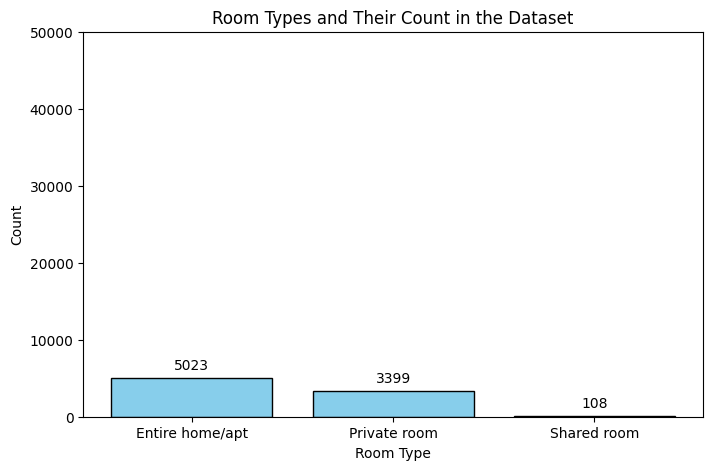

In [ ]:
room_type_counts = df['room type'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
room_type_bar = ax.bar(room_type_counts.index, room_type_counts.values, color='skyblue', edgecolor='black')

ax.bar_label(room_type_bar, labels=room_type_counts.values, padding=4)

ax.set_ylim([0, 50000])  # adjust if needed
ax.set_xlabel('Room Type')
ax.set_ylabel('Count')
ax.set_title('Room Types and Their Count in the Dataset')

plt.show()


In [ ]:
hood_group = df['neighbourhood group'].value_counts().to_frame()
hood_group

,count
neighbourhood group,
Brooklyn,3867
Manhattan,3837
Queens,669
Bronx,118
Staten Island,38
brookln,1


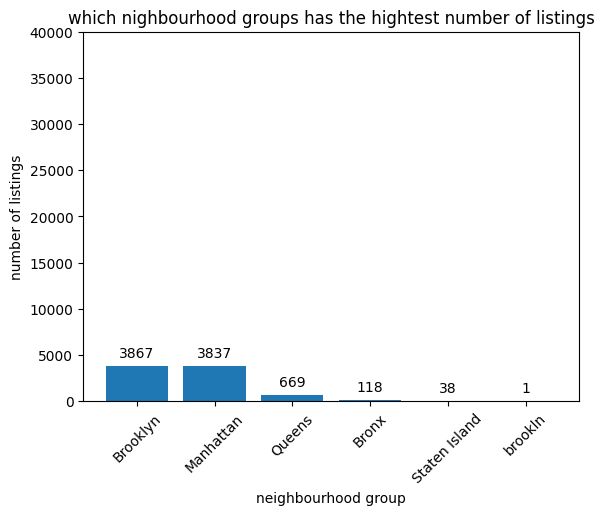

In [ ]:
hood_group_bar = plt.bar(hood_group.index, hood_group.loc[:,"count"]);
plt.bar_label(hood_group_bar,labels = hood_group.loc[:,"count"],padding =4);
plt.ylim([0,40000]);
plt.xlabel("neighbourhood group");
plt.ylabel('number of listings');
plt.xticks(rotation = 45);
plt.title('which nighbourhood groups has the hightest number of listings');


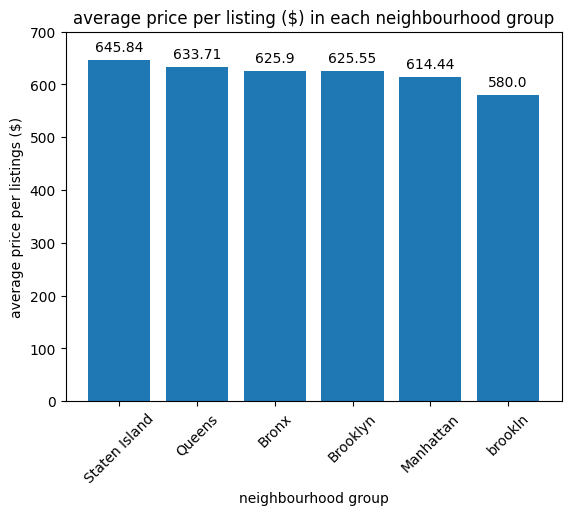

In [ ]:
#which neighbourhood grop have the highest avergae prices for airbnb listing?
avg_price = df.groupby('neighbourhood group')['price_$'].mean().sort_values(ascending = False).to_frame()
avg_price_bar = plt.bar(avg_price.index,avg_price.loc[:,'price_$']);
plt.bar_label(avg_price_bar,labels = round(avg_price.loc[:,"price_$"],2), label_type = 'edge', padding = 4);
plt.ylim([0,700]);
plt.xlabel('neighbourhood group');
plt.ylabel('average price per listings ($)');
plt.xticks(rotation = 45);
plt.title('average price per listing ($) in each neighbourhood group');


is thare a relationship between the  construction year of property and price?

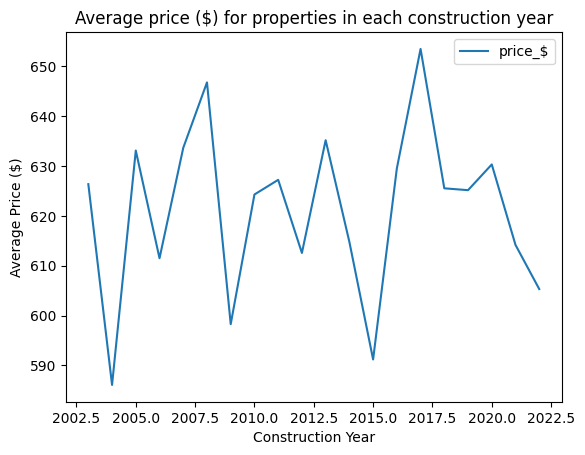

In [ ]:
df.groupby(df['construction year'])['price_$'].mean().to_frame().plot();
plt.xlabel('Construction Year');
plt.ylabel('Average Price ($)');
plt.title('Average price ($) for properties in each construction year');



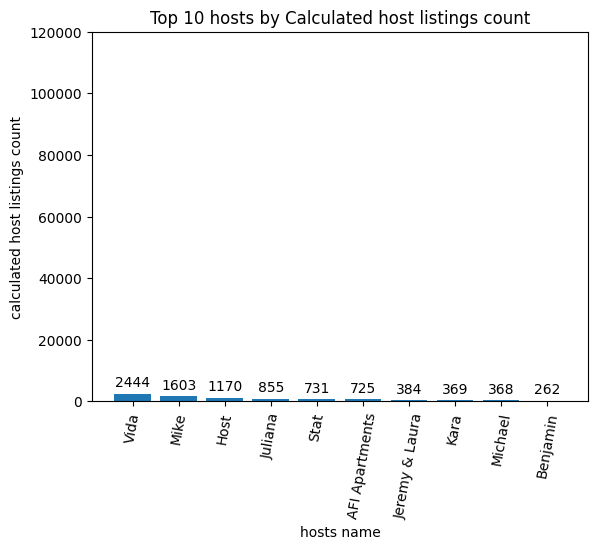

In [ ]:
#who are the top 10 hosts by calculated host ?
hosts = df.groupby('host name')['calculated host listings count'].sum().sort_values(ascending = False).nlargest(10).to_frame()
hosts_bar = plt.bar(hosts.index,hosts.loc[:,'calculated host listings count']);
plt.bar_label(hosts_bar,label = hosts.loc[:,'calculated host listings count'], label_type = 'edge' ,padding = 3);
plt.xlabel('hosts name');
plt.ylabel('calculated host listings count');
plt.xticks(rotation = 80);
plt.ylim([0, 120000]);
plt.title('Top 10 hosts by Calculated host listings count');


In [ ]:
#positive reviews
review = df.groupby('host_identity_verified')['review rate number'].mean().sort_values(ascending = False).to_frame()
review

,review rate number
host_identity_verified,
verified,3.010818
unconfirmed,3.009350


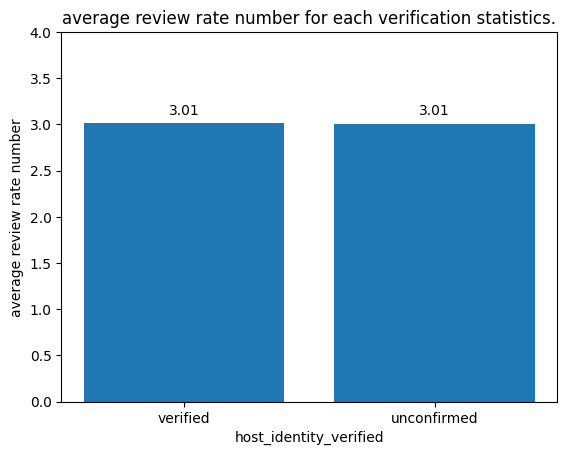

In [ ]:
review_bar = plt.bar(review.index,review.loc[:,"review rate number"]);
plt.bar_label(review_bar, labels = round(review.loc[:,"review rate number"],2), padding = 4 );
plt.ylim([0,4]);
plt.xlabel('host_identity_verified');
plt.ylabel('average review rate number');
plt.title('average review rate number for each verification statistics.');

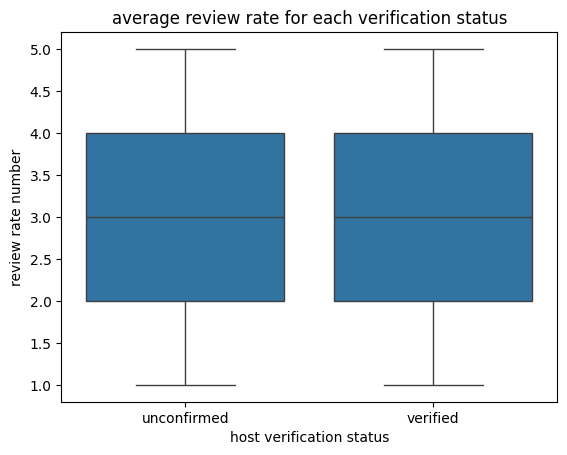

In [ ]:
base_color = sns.color_palette()[0]
sns.boxplot(data = df, x = "host_identity_verified", y = "review rate number",color = base_color);
plt.xlabel('host verification status');
plt.ylabel('review rate number');
plt.title('average review rate for each verification status');

correlation between the price of a listing

In [ ]:
df['price_$'].corr(df['service_fee_$'])

np.float64(0.9999913132990005)

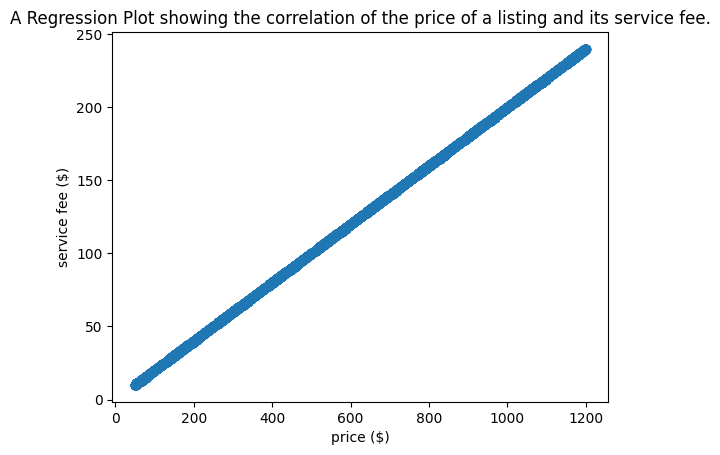

In [ ]:
sns.regplot(df, x = 'price_$', y = 'service_fee_$');
plt.xlabel('price ($)');
plt.ylabel('service fee ($)');
plt.title('A Regression Plot showing the correlation of the price of a listing and its service fee.');



In [ ]:
#what is the average review rate number
ARRN = df.groupby(['neighbourhood group','room type'])['review rate number'].mean().to_frame()
ARRN

review rate number
neighbourhood group room type                          
Bronx               Entire home/apt            2.871795
                    Private room               2.973333
                    Shared room                2.000000
Brooklyn            Entire home/apt            2.975861
                    Private room               3.083855
                    Shared room                2.718750
Manhattan           Entire home/apt            3.026359
                    Private room               2.999259
                    Shared room                3.066667
Queens              Entire home/apt            2.849498
                    Private room               3.011173
                    Shared room                3.500000
Staten Island       Entire home/apt            3.050000
                    Private room               2.555556
brookln             Private room               4.000000

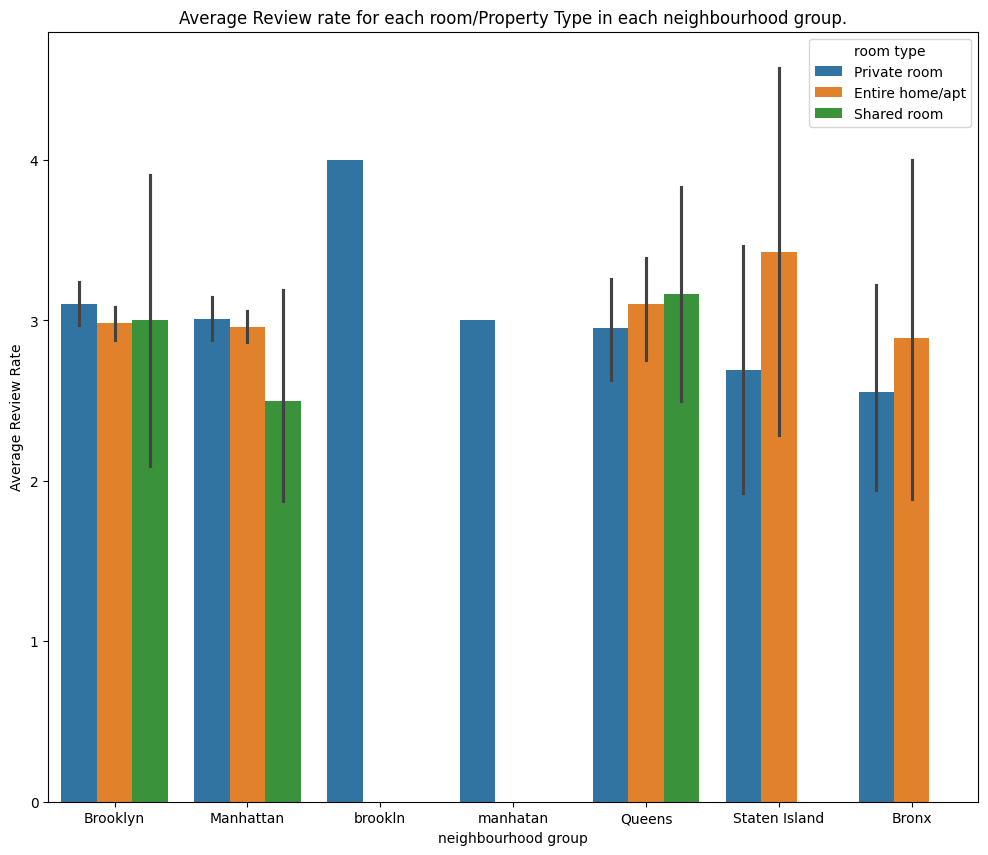

In [5]:
plt.figure(figsize =[12,10]);
sns.barplot(data = df, x= 'neighbourhood group', y = 'review rate number', hue ='room type');
plt.xlabel('neighbourhood group');
plt.ylabel('Average Review Rate');
plt.title('Average Review rate for each room/Property Type in each neighbourhood group.');

Are hosts with a higher calculated host listing count more likely to maintain availability throughout the year

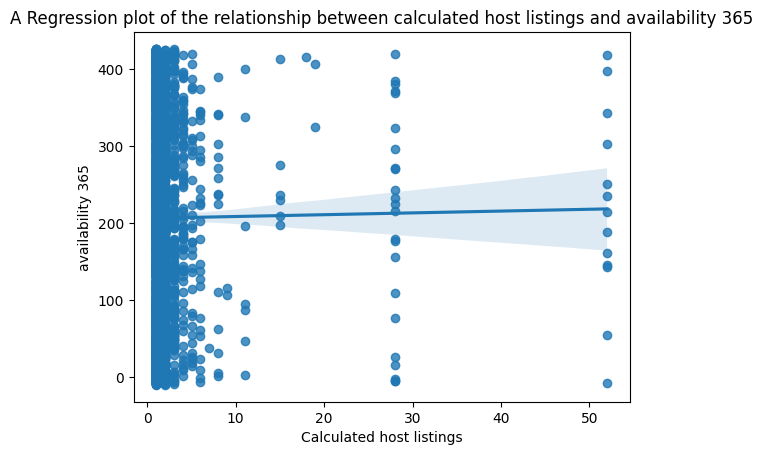

In [7]:
sns.regplot(df, x= 'calculated host listings count', y = 'availability 365');
plt.xlabel('Calculated host listings');
plt.ylabel('availability 365');
plt.title('A Regression plot of the relationship between calculated host listings and availability 365');

In [11]:
df['calculated host listings count'].corr(df['availability 365'])

np.float64(0.008661411861308872)

The Person Correlation coefficient for the association between calculated host listing and availability 365 is 0.136, indicating a weak postive correlation between the two variables

Conclusion:

The analysis of the Airbnb hotel booking dataset reveals that customer booking behavior is strongly influenced by room type, location, pricing, and host credibility. Entire homes and private rooms are the most preferred options, while listings in popular neighbourhoods command higher prices and greater demand. Hosts with verified profiles and multiple listings tend to attract more bookings, supported by positive customer reviews. Seasonal trends and minimum night requirements also affect occupancy rates and revenue potential. Overall, the study highlights that optimizing location-based pricing, maintaining host reliability, and improving customer satisfaction are the key factors for enhancing success in the Airbnb market.